# Schritt 1: CNN für Fashion-MNIST

In diesem Notebook untersuchen wir ein Convolutional Neural Network (CNN) zur Klassifikation des Fashion-MNIST-Datensatzes.

## Laufzeit für dieses Notebook ist HOCH. Nicht während der Vorlesung laufen lassen.

## Ziel

Wir bauen ein CNN mit der Architektur:

- `Conv2D(32)` → MaxPooling
- `Conv2D(64)` → MaxPooling
- Flatten
- Dense(128)
- Softmax-Ausgabe

Anschließend vergleichen wir das CNN mit den MLP-Modellen aus K10_02 und K10_03.

## Lernziele

Nach diesem Notebook sollten Sie:

- die klassische CNN-Pipeline `Conv → Pool → Conv → Pool → Flatten → Dense → Softmax` beschreiben können
- verstehen, warum CNNs für Bilddaten besser geeignet sind als Dense-Netze
- Lernkurven und Konfusionsmatrix eines CNNs interpretieren können

## Leitfragen (zum Nachdenken beim Durcharbeiten)

- Welche Accuracy erreicht das CNN – und um wie viel übertrifft es das MLP?
- Welche Klassen werden nach wie vor verwechselt? (z. B. Pullover vs. Hemd)
- Sehen Sie Overfitting in den Lernkurven?
- Hat das CNN mehr oder weniger Parameter als das MLP – und was sagt das aus?

# Schritt 2: Bibliotheken importieren

In [1]:
# ── Erste Zelle im Notebook ──
import time
notebook_start = time.time()
print("Notebook gestartet.")

Notebook gestartet.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import random

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

SEED=42
np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)

# Schritt 3: Fashion-MNIST laden
## Fashion-MNIST-Datensatz

Der Fashion-MNIST-Datensatz enthält:

- 60.000 Trainingsbilder
- 10.000 Testbilder
- Graustufenbilder mit 28 × 28 Pixeln
- 10 Klassen von Kleidungsstücken

Im Unterschied zu handgeschriebenen Ziffern sind diese Klassen schwieriger zu unterscheiden.

In [3]:
(X_train_full, y_train_full), (X_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

print("Trainingsdaten:", X_train_full.shape)
print("Testdaten:", X_test.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Trainingsdaten: (60000, 28, 28)
Testdaten: (10000, 28, 28)


# Schritt 4: Klassennamen definieren
## Klassen des Fashion-MNIST-Datensatzes

Zur besseren Interpretation ordnen wir den numerischen Labels ihre Klassennamen zu.

In [4]:
class_names = [
    "T-Shirt/Top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]
print(class_names)

['T-Shirt/Top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


# Schritt 5: Erste Visualisierung
## Beispielbilder

Wir betrachten einige Beispiele aus dem Datensatz, um ein Gefühl für die Klassen zu bekommen.

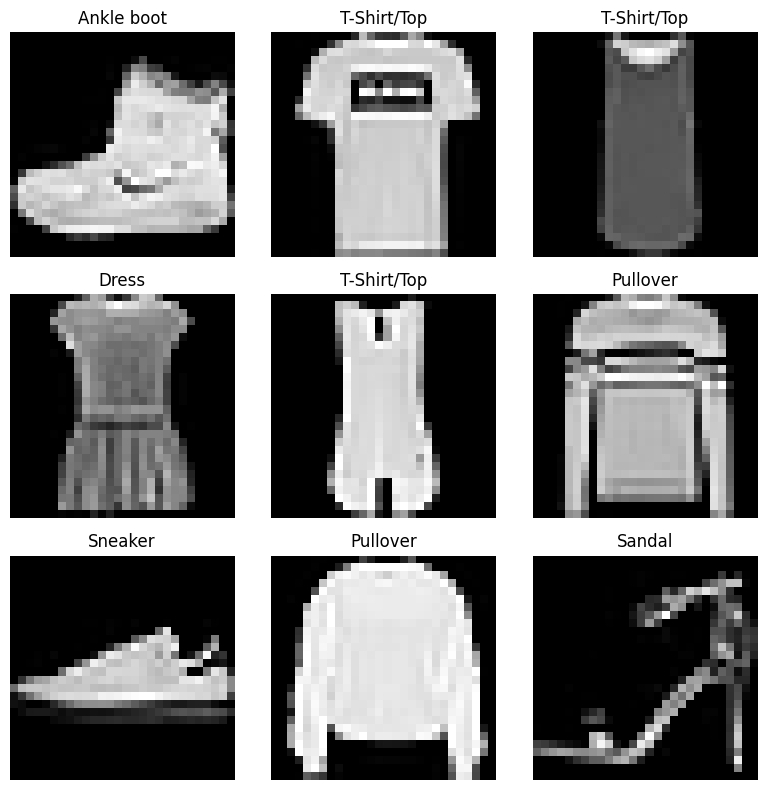

In [5]:
plt.figure(figsize=(8, 8))

for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(X_train_full[i], cmap="gray")
    plt.title(class_names[y_train_full[i]])
    plt.axis("off")

plt.tight_layout()
plt.show()

# Schritt 6: Skalierung der Daten
## Skalierung

Die Pixelwerte liegen im Bereich von 0 bis 255.

Für neuronale Netze ist es sinnvoll, diese Werte auf den Bereich [0, 1] zu skalieren.

In [6]:
X_train_full = X_train_full / 255.0
X_test = X_test / 255.0

# Schritt 7: Validierungsset abtrennen
## Train-/Validierungs-Split

Wir trennen einen Teil der Trainingsdaten als Validierungsset ab.

Warum?

- um den Trainingsverlauf zu überwachen
- um Early Stopping korrekt anzuwenden
- um Hyperparameter auf separaten Daten zu bewerten

Die Testdaten bleiben bis zur finalen Evaluation unangetastet.

In [7]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X_train_full, y_train_full, test_size=5000, random_state=SEED
)

print("Train:", X_train.shape)
print("Validation:", X_valid.shape)
print("Test:", X_test.shape)

Train: (55000, 28, 28)
Validation: (5000, 28, 28)
Test: (10000, 28, 28)


# Schritt 8: Eingabeform für das CNN anpassen
## Zusätzliche Kanaldimension für das CNN

Ein CNN erwartet Eingaben der Form `(Höhe, Breite, Kanäle)`.

Da Fashion-MNIST Graustufenbilder enthält, gibt es genau **einen** Kanal.

Daher formen wir die Daten von `(28, 28)` nach `(28, 28, 1)` um.

Merksatz: CNN-Modelle in Keras erwarten Bilder als 3D-Tensoren (Höhe, Breite, Kanäle).

In [8]:
X_train = X_train.reshape(-1, 28, 28, 1)
X_valid = X_valid.reshape(-1, 28, 28, 1)
X_test  = X_test.reshape(-1, 28, 28, 1)

print("Neue Form Trainingsdaten:    ", X_train.shape)
print("Neue Form Validierungsdaten: ", X_valid.shape)
print("Neue Form Testdaten:         ", X_test.shape)

Neue Form Trainingsdaten:     (55000, 28, 28, 1)
Neue Form Validierungsdaten:  (5000, 28, 28, 1)
Neue Form Testdaten:          (10000, 28, 28, 1)


# Schritt 9: Warum ein CNN?
## Motivation für das CNN

Die MLP-Modelle aus K10_02 und K10_03 arbeiten nach `Flatten()` nur noch mit einem Vektor.

**Problem**: Dabei geht die räumliche Struktur des Bildes vollständig verloren.

Ein CNN kann dagegen **lokale Muster** erkennen, zum Beispiel:

- Kanten und Helligkeitsübergänge
- Konturen und einfache Formen
- Texturen und Oberflächenmerkmale

**Entscheidender Vorteil**: Durch gemeinsame Gewichte (Parameterteilen) können CNNs
dasselbe Muster an jeder Stelle im Bild erkennen – **Translationsinvarianz**.

Deshalb sind CNNs für Bilddaten meist deutlich besser geeignet als reine Dense-Netze.

# Schritt 10: CNN-Architektur definieren
## CNN-Architektur

Wir verwenden das folgende Modell:

- `Conv2D(32, 3×3, ReLU)` → erkennt einfache lokale Muster
- `MaxPooling2D(2×2)` → reduziert Dimension
- `Conv2D(64, 3×3, ReLU)` → erkennt komplexere Muster
- `MaxPooling2D(2×2)` → reduziert Dimension weiter
- `Flatten()` → wandelt Feature Maps in Vektor um
- `Dense(128, ReLU)` → klassifiziert auf Basis der gelernten Merkmale
- `Dense(10, Softmax)` → Ausgabe als Wahrscheinlichkeiten

Merksatz: `Conv → Pool → Conv → Pool → Flatten → Dense → Softmax`: die klassische CNN-Pipeline.

In [9]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(28, 28, 1)),
    tf.keras.layers.Conv2D(32, kernel_size=(3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),
    tf.keras.layers.Conv2D(64, kernel_size=(3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

# Schritt 11: Modellüberblick anzeigen
## Modellübersicht

Mit `model.summary()` können wir die Architektur und die Anzahl der Parameter betrachten.

In [10]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

# Schritt 12: Manuelle Parameterberechnung
## Parameter selbst nachrechnen

Für einen Conv2D-Layer gilt:

`Anzahl_Parameter = Filtergröße_H × Filtergröße_B × Eingabekanäle × Anzahl_Filter + Anzahl_Filter (Biases)`

Wir rechnen die Parameter manuell nach und vergleichen mit dem MLP aus K10_03.

**Wichtige Beobachtung:** Das CNN hat *weniger* Parameter als das MLP – und ist trotzdem viel besser!

In [11]:
# CNN: (28,28,1) → Conv(32) → Pool → Conv(64) → Pool → Flatten → Dense(128) → Dense(10)

# Nach Conv2D(32, 3×3):  Ausgabe = (26, 26, 32)
params_conv1 = 3 * 3 * 1 * 32 + 32       # Filter (3×3×1 je Filter, 32 Filter) + Biases

# Nach MaxPool(2×2):     Ausgabe = (13, 13, 32)
# Nach Conv2D(64, 3×3):  Ausgabe = (11, 11, 64)
params_conv2 = 3 * 3 * 32 * 64 + 64      # Filter (3×3×32 je Filter, 64 Filter) + Biases

# Nach MaxPool(2×2):     Ausgabe = (5, 5, 64)
# Nach Flatten:          Ausgabe = 5 × 5 × 64 = 1.600
params_dense1 = 5 * 5 * 64 * 128 + 128   # Flatten(1600) → Dense(128)
params_dense2 = 128 * 10 + 10             # Dense(128) → Dense(10)

total_cnn = params_conv1 + params_conv2 + params_dense1 + params_dense2

print("=== Manuelle Parameterberechnung: CNN ===")
print(f"Conv2D(32, 3×3):   3×3×1×32   + 32  = {params_conv1:>8,}")
print(f"Conv2D(64, 3×3):   3×3×32×64  + 64  = {params_conv2:>8,}")
print(f"Dense(128):        1600×128   + 128 = {params_dense1:>8,}")
print(f"Dense(10):         128×10     + 10  = {params_dense2:>8,}")
print(f"{'─' * 48}")
print(f"CNN gesamt:                           {total_cnn:>8,}")
print()

mlp_b_params = 266_610  # MLP Variante B aus K10_03
print(f"MLP Variante B (K10_03):              {mlp_b_params:>8,} Parameter")
print(f"Differenz:                            {mlp_b_params - total_cnn:>8,} Parameter weniger im CNN")
print()
print(f"Prüfung mit model.summary() oben: {total_cnn:,} ✓")
print()
print("Fazit: Das CNN hat WENIGER Parameter als das MLP,")
print("       erreicht aber ~91–93 % statt ~88 % Test-Accuracy.")
print("       → Das CNN gewinnt durch räumliches Lernen, nicht durch mehr Parameter!")

=== Manuelle Parameterberechnung: CNN ===
Conv2D(32, 3×3):   3×3×1×32   + 32  =      320
Conv2D(64, 3×3):   3×3×32×64  + 64  =   18,496
Dense(128):        1600×128   + 128 =  204,928
Dense(10):         128×10     + 10  =    1,290
────────────────────────────────────────────────
CNN gesamt:                            225,034

MLP Variante B (K10_03):               266,610 Parameter
Differenz:                              41,576 Parameter weniger im CNN

Prüfung mit model.summary() oben: 225,034 ✓

Fazit: Das CNN hat WENIGER Parameter als das MLP,
       erreicht aber ~91–93 % statt ~88 % Test-Accuracy.
       → Das CNN gewinnt durch räumliches Lernen, nicht durch mehr Parameter!


# Schritt 13: Modell kompilieren
## Kompilierung des Modells

Wir verwenden:

- `sparse_categorical_crossentropy` als Loss-Funktion
- `adam` als Optimizer
- `accuracy` als Metrik

In [12]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Schritt 14: Early Stopping definieren
## Early Stopping

Early Stopping beendet das Training automatisch, wenn sich die Leistung
auf den Validierungsdaten nicht weiter verbessert.

Parameter:

- `monitor='val_loss'`
- `patience=3`
- `restore_best_weights=True`

Damit wird am Ende die beste Epoche verwendet.

In [13]:
def make_early_stop():
    return tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True
    )

# Schritt 15: CNN trainieren
## Training des CNN

Wir trainieren das Modell auf den Trainingsdaten und überwachen die Leistung
auf dem Validierungsset.

Ein Zeitstempel misst die Trainingsdauer.

In [14]:
start_time = time.time()

history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_valid, y_valid),
    callbacks=[make_early_stop()],
    verbose=1
)

elapsed = time.time() - start_time
epochen = len(history.history['loss'])
print(f"\nTrainingszeit CNN: {elapsed:.1f} Sekunden ({epochen} Epochen)")

Epoch 1/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 51s 28ms/step - accuracy: 0.8371 - loss: 0.4492 - val_accuracy: 0.8764 - val_loss: 0.3377
Epoch 2/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 48s 28ms/step - accuracy: 0.8903 - loss: 0.3015 - val_accuracy: 0.8932 - val_loss: 0.2920
Epoch 3/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 83s 28ms/step - accuracy: 0.9060 - loss: 0.2540 - val_accuracy: 0.9012 - val_loss: 0.2758
Epoch 4/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 47s 27ms/step - accuracy: 0.9185 - loss: 0.2186 - val_accuracy: 0.9058 - val_loss: 0.2667
Epoch 5/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 48s 28ms/step - accuracy: 0.9303 - loss: 0.1892 - val_accuracy: 0.9060 - val_loss: 0.2730
Epoch 6/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 81s 27ms/step - accuracy: 0.9383 - loss: 0.1649 - val_accuracy: 0.9050 - val_loss: 0.2891
Epoch 7/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 49s 28ms/step - accuracy: 0.9467 - loss: 0.1426 - val_accuracy: 0.9100 - val_loss: 0.3058

Trainingszeit CNN: 407.3 Sekunden (7 Epochen)


# Schritt 16: Lernkurven darstellen
## Lernkurven des CNN

Wir betrachten:

- Trainings-Loss und Validierungs-Loss
- Trainings-Accuracy und Validierungs-Accuracy

Leitfrage: Sehen Sie Overfitting – und wenn ja, ab welcher Epoche?

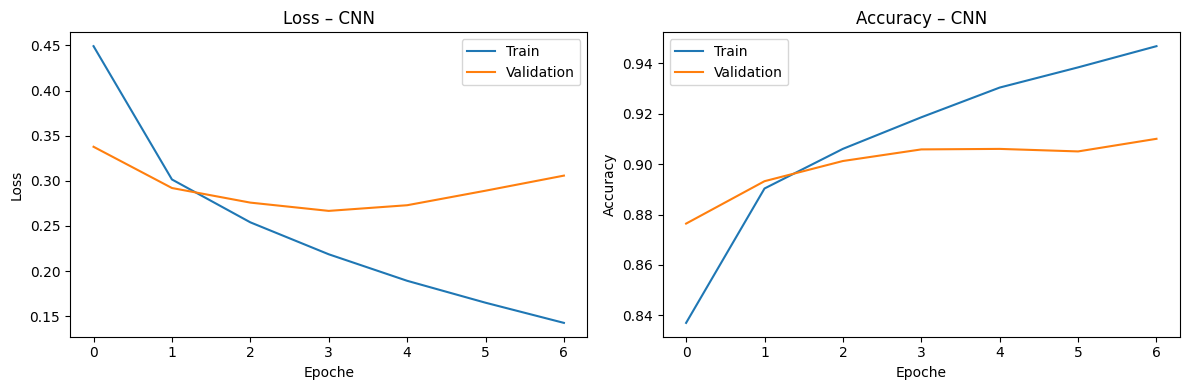

In [15]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('Loss – CNN')
plt.xlabel('Epoche')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('Accuracy – CNN')
plt.xlabel('Epoche')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

# Schritt 17: Evaluation
## Evaluation des CNN

Zunächst betrachten wir die Leistung auf dem Validierungsset,
anschließend die finale Accuracy auf dem Testset.

In [16]:
val_loss, val_acc = model.evaluate(X_valid, y_valid, verbose=0)
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)

print("Validation-Accuracy (CNN):", val_acc)
print("Test-Accuracy (CNN):", test_acc)

Validation-Accuracy (CNN): 0.9057999849319458
Test-Accuracy (CNN): 0.9053999781608582


# Schritt 18: Konfusionsmatrix
## Welche Klassen werden noch verwechselt?

Die Konfusionsmatrix zeigt, welche Klassen korrekt erkannt werden
und welche Klassen weiterhin verwechselt werden.

Beobachtungsauftrag:
- Welche Klassen werden am häufigsten verwechselt?
- Hat das CNN weniger Verwechslungen als das MLP (K10_02/K10_03)?

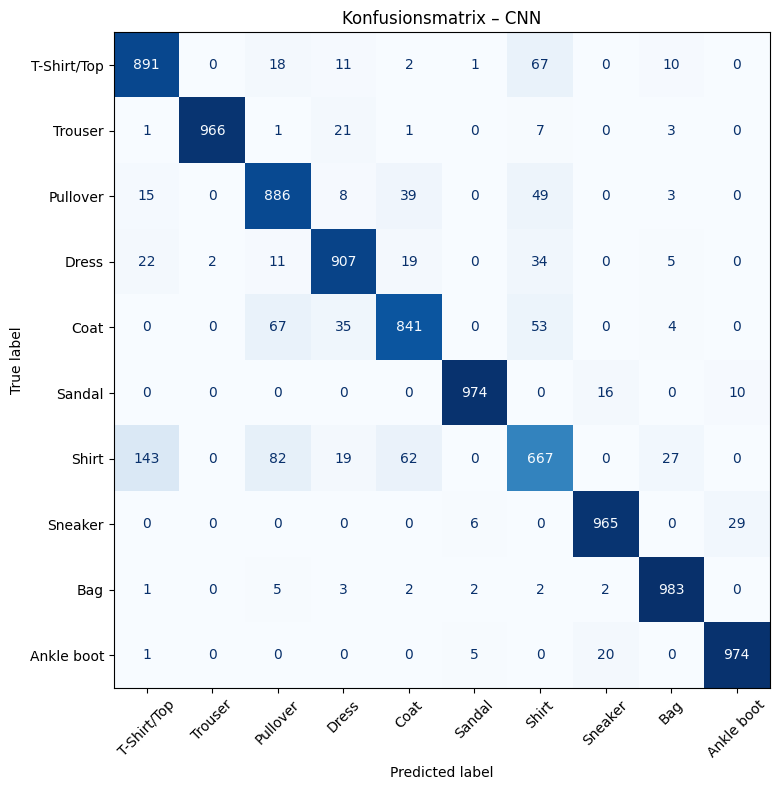

In [17]:
y_pred = model.predict(X_test, verbose=0)
y_pred_classes = np.argmax(y_pred, axis=1)

cm = confusion_matrix(y_test, y_pred_classes)

fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, cmap='Blues', xticks_rotation=45, colorbar=False)
plt.title("Konfusionsmatrix – CNN")
plt.tight_layout()
plt.show()

# Schritt 19: Vergleich mit den MLP-Modellen
## Vergleich CNN vs. MLP (K10_02 und K10_03)

Bisherige Ergebnisse der MLP-Modelle:

- MLP Variante A (1 Hidden Layer, Adam, K10_02): ca. **88 %**
- MLP Variante A mit KerasTuner (K10_02): ca. **88 %**
- MLP Variante B (2 Hidden Layers, SGD, K10_03): ähnlich oder leicht schlechter

Typisches Ergebnis für das CNN:

- CNN: ca. **91–93 %**

## Leitfrage:
Um wie viel übertrifft das CNN das MLP – und warum?

In [18]:
mlp_reference = 0.88
improvement = test_acc - mlp_reference

print("=" * 52)
print("Vergleich CNN vs. MLP auf Fashion-MNIST")
print("=" * 52)
print(f"MLP (Referenz K10_02/K10_03):   ~{mlp_reference:.0%}")
print(f"CNN (dieses Notebook):           {test_acc:.2%}")
print(f"Verbesserung:                   +{100 * improvement:.2f} Prozentpunkte")
print()
print(f"Trainingszeit CNN: {elapsed:.1f} s ({epochen} Epochen)")

Vergleich CNN vs. MLP auf Fashion-MNIST
MLP (Referenz K10_02/K10_03):   ~88%
CNN (dieses Notebook):           90.54%
Verbesserung:                   +2.54 Prozentpunkte

Trainingszeit CNN: 407.3 s (7 Epochen)


In [19]:
# ── Letzte Zelle im Notebook ──
total = time.time() - notebook_start
minuten = int(total // 60)
sekunden = int(total % 60)
print(f"Gesamtlaufzeit: {minuten} min {sekunden} sek")

Gesamtlaufzeit: 7 min 12 sek


# Schritt 20: Merksatz
## Merksatz

**Fashion-MNIST zeigt klar: CNNs lernen Bildmerkmale, die einfache Dense-Netze nicht erfassen können.**

Warum ist das CNN besser?

- Es nutzt die **räumliche Struktur** der Bilder aus
- Durch **gemeinsame Gewichte** (Translationsinvarianz) braucht es sogar **weniger Parameter** als das MLP
- Es lernt hierarchisch: einfache Kanten → Konturen → abstrakte Merkmale

Ausblick: Für noch bessere Ergebnisse gibt es Regularisierungstechniken
wie Dropout, Batch Normalization und Data Augmentation – diese werden
im nächsten Teil des Kapitels (CIFAR-10) eingesetzt.